## Regression

Mainly to create graphs to illustrate omitted variable bias

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

def get_even_numbers(n):
    return np.arange(0, n, 2)

get_even_numbers   = get_even_numbers(10)


In [2]:
df = pd.DataFrame({'midterm': np.random.uniform(20, 100, 100)})

In [3]:
# add a column to df named AC which is a random uniform distribution between 0 and 1
df['AC'] = np.random.uniform(0, 1, 100) 
df['class'] = np.where(df['AC'] > 0.5, 1, 0)

In [4]:
df.describe()

,midterm,AC,class
count,100.000000,100.000000,100.000000
mean,66.409736,0.497658,0.520000
std,22.148245,0.297021,0.502117
min,20.663186,0.008791,0.000000
25%,52.554252,0.224066,0.000000
50%,67.204669,0.528928,1.000000
75%,84.868002,0.769729,1.000000
max,99.112958,0.996314,1.000000


In [5]:
df['score'] = 10 + 0.75*df['midterm'] + 20 * df['class'] +  np.random.normal(0, 20, 100)

In [6]:
# drop all rows where score is greater than 100
df = df[df['midterm'] > 0]

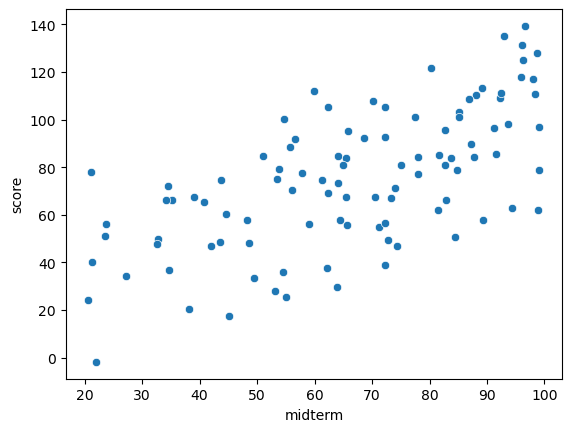

In [7]:
sns.scatterplot(x='midterm', y='score', data=df);

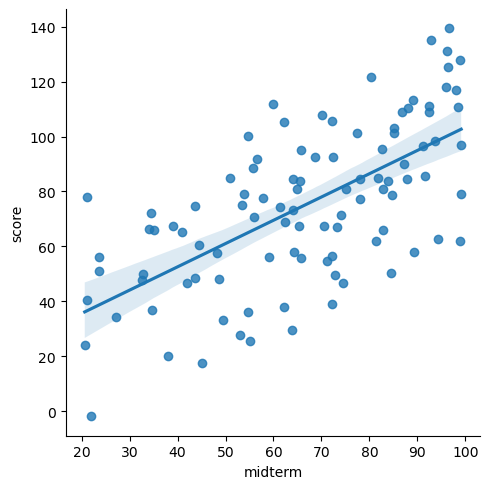

In [8]:
sns.lmplot(x='midterm', y='score', data=df);

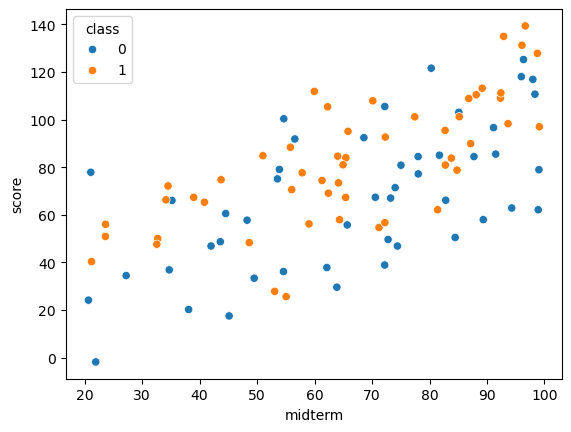

In [9]:
sns.scatterplot(x='midterm', y='score', hue='class', data=df);

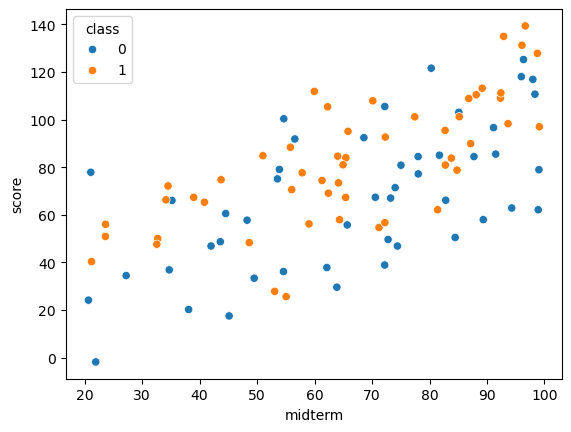

In [10]:
sns.scatterplot(x='midterm', y='score', hue='class', data=df);

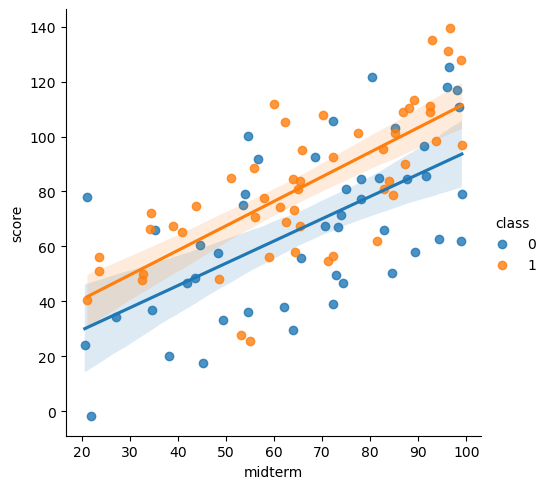

In [11]:
sns.lmplot(x='midterm', y='score', hue='class', data=df);

In [12]:
import econtools.metrics as mt

ModuleNotFoundError: No module named 'econtools'

In [15]:
import statsmodels.api as sm

# Define the dependent and independent variables
X = df['midterm']
y = df['score']
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     70.77
Date:                Fri, 14 Feb 2025   Prob (F-statistic):           3.32e-13
Time:                        09:37:21   Log-Likelihood:                -450.91
No. Observations:                 100   AIC:                             905.8
Df Residuals:                      98   BIC:                             911.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.6620      7.050      2.647      0.0

In [16]:
# Define the dependent and independent variables
X = df[['midterm', 'class']]
y = df['score']
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     46.00
Date:                Fri, 14 Feb 2025   Prob (F-statistic):           8.93e-15
Time:                        09:37:56   Log-Likelihood:                -444.74
No. Observations:                 100   AIC:                             895.5
Df Residuals:                      97   BIC:                             903.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5878      7.036      1.505      0.1

In [25]:
results = mt.reg(df, 'score', ['midterm','class'], addcons=True)

In [26]:
results.summary.round(3)

,coeff,se,t,p>t,CI_low,CI_high
midterm,0.813,0.094,8.686,0.000,0.627,0.999
class,19.894,4.212,4.723,0.000,11.534,28.254
_cons,3.637,6.477,0.562,0.576,-9.218,16.492
